In [ ]:
# pip install tensorflow


     ---------------------------------------- 0.0/49.8 kB ? eta -:--:--
     ---------------------------------------- 49.8/49.8 kB 2.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/376.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/376.0 MB 5.9 MB/s eta 0:01:04
   ---------------------------------------- 0.8/376.0 MB 8.5 MB/s eta 0:00:45
   ---------------------------------------- 1.7/376.0 MB 12.1 MB/s eta 0:00:32
   ---------------------------------------- 2.7/376.0 MB 14.3 MB/s eta 0:00:27
   ---------------------------------------- 3.7/376.0 MB 16.8 MB/s eta 0:00:23
    --------------------------------------- 4.9/376.0 MB 18.4 MB/s eta 0:00:21
    --------------------------------------- 6.1/376.0 MB 18.5 MB/s eta 0:00:21
    --------------------------------------- 7.1/376.0 MB 19.8 MB/s eta 0:00:19
    --------------------------------------- 7.8/376.0 MB 18.4 MB/s eta 0:00:21
    --------------------------------------- 8.7/376.0 MB 18.6 MB/s e

In [ ]:
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.signal import welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# === LOAD & PREP DATA ===
# Load Ra files
ra1 = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\Ra1.mat')['Ra1']
ra2 = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\Ra2.mat')['Ra2']
ra3 = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\Ra3.mat')['Ra3']



In [5]:
# Load Ra files
ra1 = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\Ra1.mat')['Ra1']
ra2 = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\Ra2.mat')['Ra2']
ra3 = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\Ra3.mat')['Ra3']



# Merge into one big 3D array → shape: (12, 15000, 75)
Xa_all = np.concatenate([ra1, ra2, ra3], axis=2)

# Extract only V1–V6 (indices 6 to 11)
Xa_v1_v6 = Xa_all[6:12, :, :]  # shape: (6, 15000, 75)

# Rearrange to (75 patients, 15000 time steps, 6 leads)
X = np.transpose(Xa_v1_v6, (2, 1, 0))  # shape: (75, 15000, 6)



In [8]:
# === LABELS ===

# Load recurrence labels
indrecur = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\indrecur.mat')['indrecur'].flatten() - 1
indnonrecur = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\indnonrecur.mat')['indnonrecur'].flatten() - 1

# Create label vector: 0 = no recurrence, 1 = recurrence
y = np.zeros(75)
y[indrecur] = 1


In [9]:
# Feature extraction function
def extract_features(signal, fs=256):
    features = []
    for lead in range(signal.shape[1]):
        x = signal[:, lead]
        features.append(np.mean(x))
        features.append(np.std(x))
        features.append(np.max(x) - np.min(x))
        f, Pxx = welch(x, fs=fs)
        features.append(np.sum(Pxx))  # signal power
        features.append(np.argmax(Pxx))  # peak frequency index
        features.append(entropy(np.abs(Pxx + 1e-8)))  # spectral entropy
    return np.array(features)

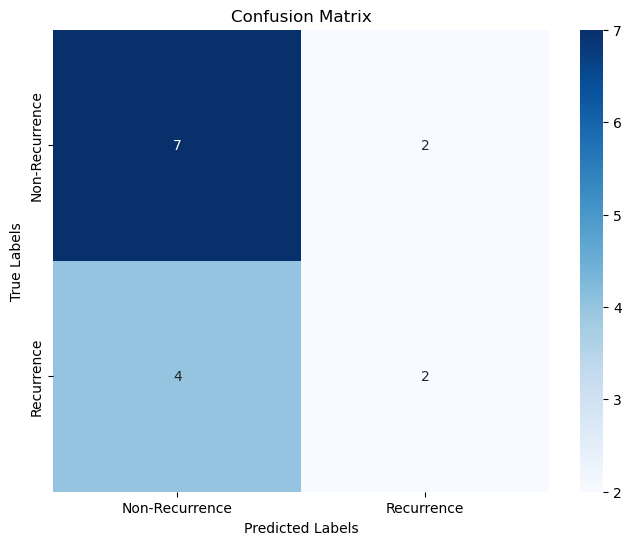

accuracy_score 0.6
classification_report {'0.0': {'precision': 0.6363636363636364, 'recall': 0.7777777777777778, 'f1-score': 0.7, 'support': 9.0}, '1.0': {'precision': 0.5, 'recall': 0.3333333333333333, 'f1-score': 0.4, 'support': 6.0}, 'accuracy': 0.6, 'macro avg': {'precision': 0.5681818181818181, 'recall': 0.5555555555555556, 'f1-score': 0.55, 'support': 15.0}, 'weighted avg': {'precision': 0.5818181818181818, 'recall': 0.6, 'f1-score': 0.58, 'support': 15.0}}


In [10]:


# Extract features for each patient
X_features = np.array([extract_features(x) for x in X])  # [75, features]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, stratify=y, random_state=42)

# Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Recurrence', 'Recurrence'], yticklabels=['Non-Recurrence', 'Recurrence'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


print("accuracy_score",acc)
print("classification_report", report) 



In [12]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

#Compute sample weights for class balancing
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Train a Gradient Boosting classifier with class balancing
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_clf.fit(X_train, y_train, sample_weight=sample_weights)

# Predict and evaluate
y_pred = gb_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)


In [13]:
acc, cm, report

(0.4,
 array([[4, 5],
        [4, 2]], dtype=int64),
 {'0.0': {'precision': 0.5,
   'recall': 0.4444444444444444,
   'f1-score': 0.47058823529411764,
   'support': 9.0},
  '1.0': {'precision': 0.2857142857142857,
   'recall': 0.3333333333333333,
   'f1-score': 0.3076923076923077,
   'support': 6.0},
  'accuracy': 0.4,
  'macro avg': {'precision': 0.39285714285714285,
   'recall': 0.38888888888888884,
   'f1-score': 0.3891402714932127,
   'support': 15.0},
  'weighted avg': {'precision': 0.4142857142857143,
   'recall': 0.4,
   'f1-score': 0.40542986425339367,
   'support': 15.0}})

In [34]:
# Load Ra files
rva1 = sio.loadmat('C:\\Users\\USER\\Downloads\\asci\\Rva1.mat')['Rva1']
rva2 = sio.loadmat('C:\\Users\\USER\\Downloads\\asci\\Rva2.mat')['Rva2']
rva3 = sio.loadmat('C:\\Users\\USER\\Downloads\\asci\\Rva3.mat')['Rva3']



# Merge into one big 3D array → shape: (12, 15000, 75)
Rva_all = np.concatenate([rva1, rva2, rva3], axis=2)

# Extract only V1–V6 (indices 6 to 11)
Rva_v1_v6 = Rva_all[6:12, :, :]  # shape: (6, 15000, 75)

# Rearrange to (75 patients, 15000 time steps, 6 leads)
Rva = np.transpose(Rva_v1_v6, (2, 1, 0))  # shape: (75, 15000, 6)

In [35]:
##ANN for Ventricular activity

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Input, TimeDistributed
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Split your data (Xva and Ra must be loaded as described before)
X_train, X_test, y_train, y_test = train_test_split(Rva, X, test_size=0.2, random_state=42)

# Build the ANN model
model = Sequential([
    Input(shape=(15000, 6)),
    Conv1D(64, kernel_size=7, activation='relu', padding='same'),
    Dropout(0.2),
    Conv1D(64, kernel_size=5, activation='relu', padding='same'),
    Dropout(0.2),
    Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    TimeDistributed(Dense(6))
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train it
history = model.fit(X_train, y_train, epochs=10, batch_size=4, validation_split=0.2)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test.flatten(), y_pred.flatten())
print("Test MSE:", mse)


Epoch 1/10


KeyboardInterrupt: 

In [36]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Assume Rva = input [75, 15000, 6]
# Assume Ra = target [75, 15000, 6]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(Rva, X, test_size=0.2, random_state=42)

# Build LSTM model
model = Sequential([
    Input(shape=(15000, 6)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    TimeDistributed(Dense(6, activation='linear'))
])

model.compile(optimizer='adam', loss='mse')

# Train it
history = model.fit(X_train, y_train, epochs=10, batch_size=4, validation_split=0.2)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test.flatten(), y_pred.flatten())
print("Test MSE:", mse)


Epoch 1/10


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Check for GPU
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Using GPU:", tf.test.is_gpu_available(cuda_only=True))

# Optional: log device placement
tf.debugging.set_log_device_placement(True)

# Optional: Restrict to first GPU if you have more than one
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        tf.config.set_visible_devices(gpus[0], 'GPU')
    except RuntimeError as e:
        print(e)

# Assume Rva = input [75, 15000, 6]
# Assume Ra = target [75, 15000, 6]
# Rva = np.random.rand(75, 15000, 6)
# Ra = np.random.rand(75, 15000, 6)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(Rva, X, test_size=0.2, random_state=42)

# Build LSTM model
model = Sequential([
    Input(shape=(15000, 6)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    TimeDistributed(Dense(6, activation='linear'))
])

model.compile(optimizer='adam', loss='mse')

# Train it
history = model.fit(X_train, y_train, epochs=10, batch_size=4, validation_split=0.2)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test.flatten(), y_pred.flatten())
print("Test MSE:", mse)


Num GPUs Available: 0
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
Using GPU: False
Epoch 1/10


In [15]:
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout

# === LOAD & PREP DATA ===

# Load Ra files
ra1 = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\Ra1.mat')['Ra1']
ra2 = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\Ra2.mat')['Ra2']
ra3 = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\Ra3.mat')['Ra3']




In [16]:




# Merge into one big 3D array → shape: (12, 15000, 75)
Xa_all = np.concatenate([ra1, ra2, ra3], axis=2)

# Extract only V1–V6 (indices 6 to 11)
Xa_v1_v6 = Xa_all[6:12, :, :]  # shape: (6, 15000, 75)

# Rearrange to (75 patients, 15000 time steps, 6 leads)
X = np.transpose(Xa_v1_v6, (2, 1, 0))  # shape: (75, 15000, 6)



In [17]:
rva1 = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\Rva1.mat')['Rva1']
rva2 = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\Rva2.mat')['Rva2']
rva3 = sio.loadmat('C:\\Users\\praba\\Documents\\GitHub\\UCA-M2-SEMESTER2\\bio medical signal processing\\lab assignments\\Atrial_prabal_ghosh\\Rva3.mat')['Rva3']


In [18]:
Rva_all = np.concatenate([rva1, rva2, rva3], axis=2)
Rva_v1_v6 = Rva_all[6:12, :, :]  # Extract V1–V6
Rva = np.transpose(Rva_v1_v6, (2, 1, 0))  # Rearrange to (75, 15000, 6)

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, TimeDistributed, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Check for GPU
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
tf.debugging.set_log_device_placement(True)

# Enable memory growth for GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Assume Rva = input [75, 15000, 6]
# Assume Ra = target [75, 15000, 6]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(Rva, X, test_size=0.2, random_state=42)

# Build BiLSTM model
model = Sequential([
    Input(shape=(15000, 6)),
    Bidirectional(LSTM(64, return_sequences=True)),  # First BiLSTM layer
    Dropout(0.2),
    Bidirectional(LSTM(64, return_sequences=True)),  # Second BiLSTM layer
    Dropout(0.2),
    TimeDistributed(Dense(6, activation='linear'))  # Output layer
])

model.compile(optimizer='adam', loss='mse')

# Train the model on GPU
with tf.device('/GPU:0'):  # Explicitly specify GPU
    history = model.fit(X_train, y_train, epochs=10, batch_size=4, validation_split=0.2)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test.flatten(), y_pred.flatten())
print("Test MSE:", mse)

AttributeError: module 'tensorflow._api.v2.compat.v2.__internal__' has no attribute 'register_load_context_function'